Nama : Ruben Sibarani

NIM  : 42324037

D3 Teknologi Informasi

=== Distance Matrix (Euclidean) ===
          a         b         c         d         e         f
a  0.000000  0.707107  5.656854  3.605551  4.242641  3.201562
b  0.707107  0.000000  4.949747  2.915476  3.535534  2.500000
c  5.656854  4.949747  0.000000  2.236068  1.414214  2.500000
d  3.605551  2.915476  2.236068  0.000000  1.000000  0.500000
e  4.242641  3.535534  1.414214  1.000000  0.000000  1.118034
f  3.201562  2.500000  2.500000  0.500000  1.118034  0.000000


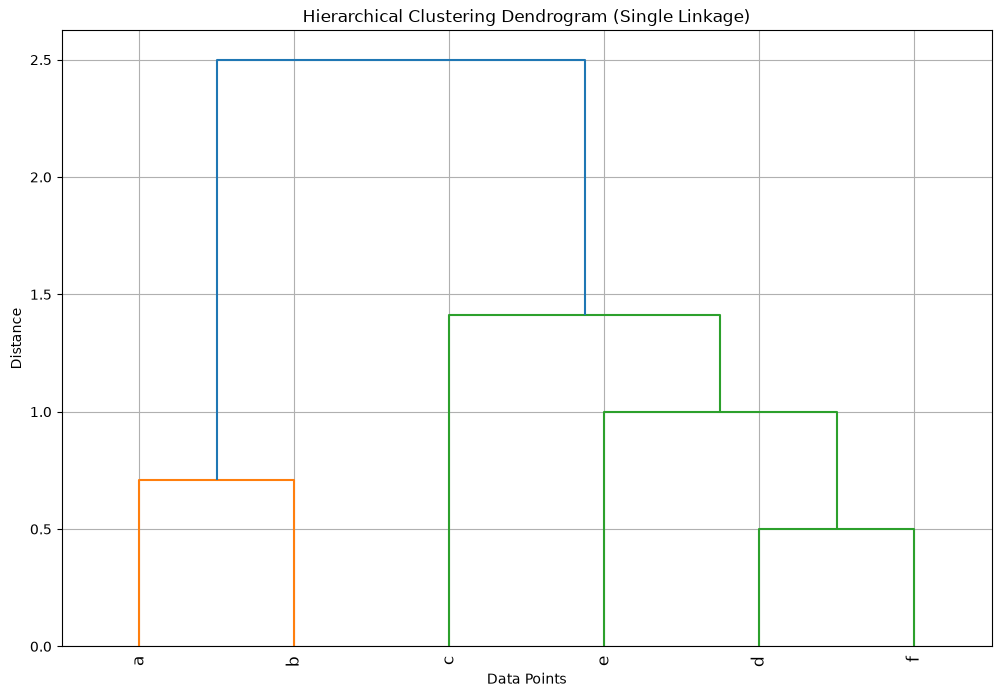

In [1]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt
# 1. Dataset sederhana
data = np.array([
 [1.0, 1.0], # a
 [1.5, 1.5], # b
 [5.0, 5.0], # c
 [3.0, 4.0], # d
 [4.0, 4.0], # e
 [3.0, 3.5] # f
])
# 2. Hitung Distance Matrix (Euclidean Distance)
distance_matrix = pdist(data, metric='euclidean')
distance_df = pd.DataFrame(squareform(distance_matrix),
 columns=['a', 'b', 'c', 'd', 'e', 'f'],
 index=['a', 'b', 'c', 'd', 'e', 'f'])
# 3. Tampilkan Distance Matrix
print("=== Distance Matrix (Euclidean) ===")
print(distance_df)
# 4. Hierarchical Clustering (Single Linkage)
linked = linkage(data, method='single')
# 5. Plot Dendrogram
plt.figure(figsize=(12, 8))
plt.title("Hierarchical Clustering Dendrogram (Single Linkage)")
dendrogram(linked, labels=['a', 'b', 'c', 'd', 'e', 'f'], leaf_rotation=90)
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Single Linkage:
Proses penggabungan awal terjadi pada titik d dan f (jarak = 0.5), disusul penggabungan dengan e (jarak = 1.0), c (jarak ≈ 1.41), dan klaster {a, b} pada jarak 0.71. Penggabungan akhir dari seluruh titik berada pada jarak 2.5. Nilai jarak ini merupakan yang paling rendah karena hanya mengukur jarak terdekat (minimum distance) antar-klaster.

In [2]:
import pandas as pd
df = pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
x = df.iloc[:, [3, 4]].values


In [4]:
from sklearn.preprocessing import StandardScaler
data_scaler = StandardScaler()
scaled_data = data_scaler.fit_transform(x)
scaled_data.shape

(200, 2)

In [5]:
from scipy.cluster.hierarchy import linkage, dendrogram
clustering = linkage(scaled_data, method="complete", metric="euclidean")

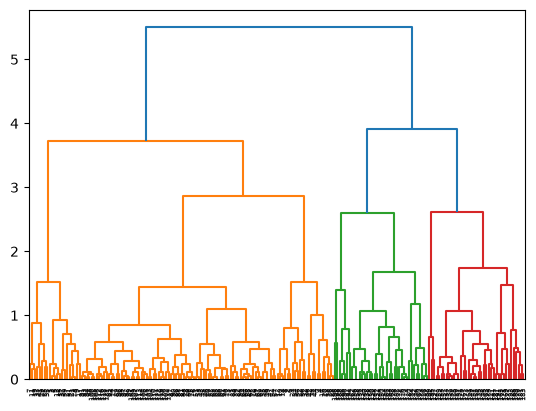

In [6]:
import matplotlib.pyplot as plt
dendrogram(clustering)
plt.show()

================================================================

Tugas

Pada percobaan pertama dengan dataset sederhana, bandingkan hasil plot dendrogram single linkage dengan complete linkage
dan average linkag

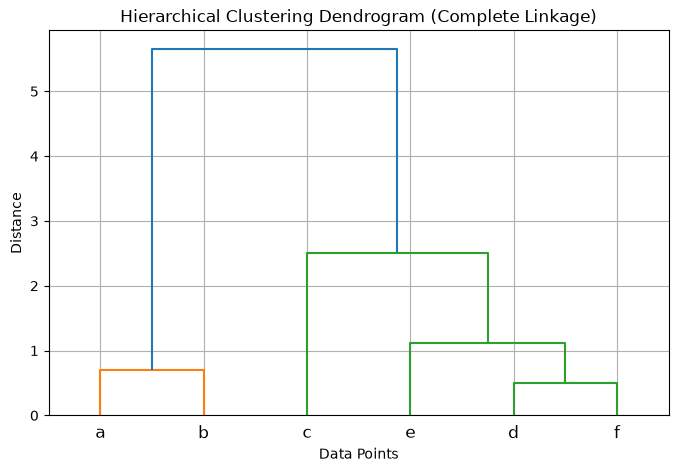

In [9]:
linked_complete = linkage(data, method="complete")

plt.figure(figsize=(8, 5))
plt.title("Hierarchical Clustering Dendrogram (Complete Linkage)")
dendrogram(linked_complete, labels=["a", "b", "c", "d", "e", "f"])
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Average Linkage
Memiliki hirarki urutan penggabungan titik yang mirip dengan Single Linkage, namun penggabungan klaster utama {a, b} dengan {c, d, e, f} baru terjadi pada jarak ≈ 3.83. Nilai jarak ini lebih tinggi karena memperhitung rata-rata jarak dari seluruh pasangan data antar-klaster.

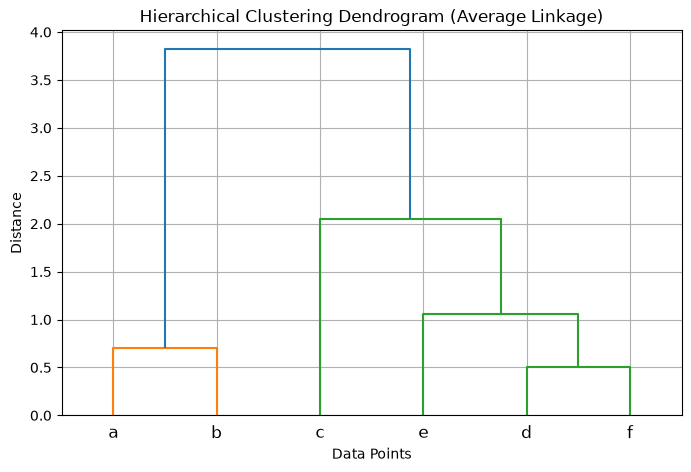

In [10]:
linked_average = linkage(data, method="average")

plt.figure(figsize=(8, 5))
plt.title("Hierarchical Clustering Dendrogram (Average Linkage)")
dendrogram(linked_average, labels=["a", "b", "c", "d", "e", "f"])
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.grid(True)
plt.show()

Complete Linkage
Urutan pembentukan klaster tetap konsisten, tetapi penggabungan akhir berada pada tingkat jarak terbesar, yaitu 5.66. Hal ini terjadi karena metode ini mengukur jarak berdasarkan titik terjauh (maximum distance) antar-klaster.